<a href="https://colab.research.google.com/github/Andres-Gress/Simulacion-I/blob/main/PruebaDeRachas_Simu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PRUEBA DE RACHAS
---

Para esta prueba se considera la siguiente prueba de hipótesis:

$$H_0: \text{ Los números de la muestra } \{x_i\} \text{ son independientes}$$

$$H_a: \text{ Los números de la muestra } \{x_i\} \text{ NO son independientes}$$

Para ello, se realizan los siguientes pasos:

1. **PASO 1:** Determine la secuencia S de $0$ y $1$ así:

$$\text{ Si } x_i \leq x_{i-1} \text{ escribir } 0$$

$$\text{ Si } x_i > x_{i-1} \text{ escribir } 1$$ La secuencia S contiene $n-1$ números

2. **PASO 2:** Contar el número de rachas observadas $C_0.$ Una racha viene dada por el número de ceros o unos consecutivos que la forman.

3. **PASO 3:** Calcule el valor esperado y la varianza del número de rachas, así como el estadistíco $Z_0$ mediante:

$$\mu_{C_0}= \frac{2n-1}{3}, \quad  \sigma_{C_0}^2=\frac{16n-29}{90}, \quad Z_0=\frac{C_0-\mu_{C_0}}{\sigma_{C_0}}$$

Dado que $C_0$ sigue una distribución normal de media $\mu_{C_0},$ y $Z_0$ una distribución normal $(0,1).$ El intervalo de aceptación es:

$$-Z_{\frac{\alpha}{2}} \leq Z_0 \leq Z_{\frac{\alpha}{2}}$$

---

**Solución:**

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

Se importan las librerias necesarias para realizar los cálculos.
Cabe resaltar:

*   scipy.stats para encontrar el punto crítico



In [4]:
url = 'https://raw.githubusercontent.com/Andres-Gress/Simulacion-I/refs/heads/main/datos.txt' #Url de github en raw para llamarlo posteriormente

data = pd.read_csv(url, header=None) #Obtiene los archivos del URL y se indica que no hay encabezados
data = data.dropna(axis=1, how='all')  #Elimina columnas de NaN que se generan por default
datos=list(data.iloc[0]) #Convierte en una lista de datos phyton

M=np.array(datos).reshape(-1,5) #Me convierte los datos en una matriz de 5 columnas
N=M.T #Traspone la Matriz
G=list(N.reshape(-1,1)) #Convierte la matriz en una sola columna

Se extrae un conjunto de datos en GitHub y se convierte en una lista; sin embargo hay una manera concreta para realizar esta prueba, por lo que se convierte a matriz de 5 columnas dicha lista, se transpone y se convierte nuevamente en una lista para operar con los datos, pero en el orden deseado

In [6]:
def prueba_rachas(G,a):
  rachas=[]
  n=len(G)
  for i in range(n-1):
    if G[i+1] > G[i]:
      rachas.append(1)
    else:
      rachas.append(0)
  c0=1

  for i in range(len(rachas)-1):
    if rachas[i] == rachas[i+1]:
      c0=c0
    else:
      c0+=1

  mu = (2*n-1)/3
  sigma = np.sqrt((16*n-29)/90)
  z0 = (c0-mu)/sigma

  print("El estadistico de prueba es: ",z0)

  z_critico = norm.ppf(1 - a/2)
  print("El punto crítico es: ",z_critico)

  if abs(z0) > z_critico:
    print("Rechazar H0: Los números de la muestra son independientes")
  else:
    print("No rechazar H0: Los números de la muestra son independientes")

Se crea la función que calcula las rachas de 0 y 1 y se cuentan para obtener $C_0$ posteriormente se obtiene la media y varianza para así obtener el estadístico de prueba.

Finalmente se calcula el punto crítico dado un nivel de significancia y se compara con $Z_0$ para concluir si se rechaza o no se rechaza $H_0$

In [7]:
a=0.05
prueba_rachas(G,a)

El estadistico de prueba es:  0.8776161218256837
El punto crítico es:  1.959963984540054
No rechazar H0: Los números de la muestra son independientes


Resultados de la prueba para $\alpha=5\%$.
No se rechaza $H_0,$ por lo que los números de la muestra son independientes.

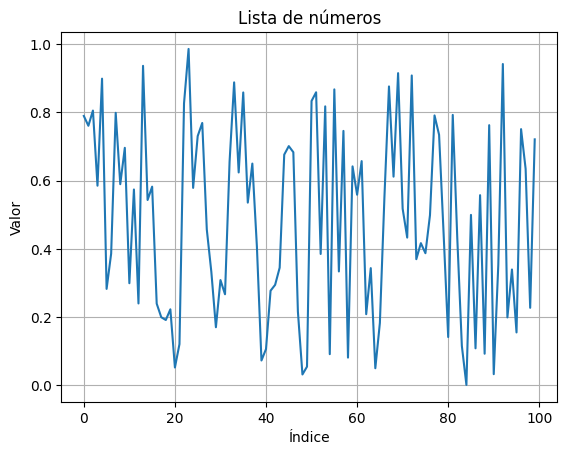

In [12]:
plt.plot(G)
plt.title('Lista de números')
plt.xlabel('Índice')
plt.ylabel('Valor')
plt.grid()
plt.show()

Gráfica de la lista de números, en el eje $x$ se encuentran los números que ahy, es decir hay 100 valores y en el eje $y$ el valor de los mismos.